In [1]:
from pathlib import Path
import sys

import cv2
import numpy as np
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt

# Adjust this if your notebook is not in the repo root
REPO_ROOT = Path(".").resolve()  # or Path("..").resolve() etc.
sys.path.append(str(REPO_ROOT))

from src.config.default import get_cfg_defaults
from src.lightning.lightning_loftr import PL_LoFTR


/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/src/loftr/loftr_module/linear_attention.py:36: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/src/loftr/loftr_module/linear_attention.py:74: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/src/loftr/loftr_module/transformer_utils.py:40: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/home/nail/miniconda3/envs/imw/lib/python3.8/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is d

In [7]:
def load_gray(path, resize=None):
    """
    Load image as grayscale float32 in [0,1].
    Works for RGB and 16-bit thermal (Boson).
    """
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Could not read image at {path}")

    # If 3-channel, convert to gray
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = img.astype(np.float32)

    max_val = img.max()
    if max_val > 1.0:
        # Heuristic: 16-bit vs 8-bit
        if max_val > 255:
            img /= 65535.0
        else:
            img /= 255.0

    if resize is not None:
        img = cv2.resize(img, (resize, resize), interpolation=cv2.INTER_AREA)

    return img  # H x W, float32 in [0,1]


def build_matcher(cfg_path, ckpt_path, imgresize=None, thr=None):
    """
    Build PL_LoFTR in test mode, on CPU, METHOD=matchanything_eloftr.
    """
    config = get_cfg_defaults()
    config.merge_from_file(str(cfg_path))

    pl.seed_everything(config.TRAINER.SEED)

    # Use MatchAnything ELoFTR branch
    config.METHOD = "matchanything_eloftr"

    # Optional: ROPE/NPE resize if used in config
    if hasattr(config.LOFTR.COARSE, "ROPE") and config.LOFTR.COARSE.ROPE:
        assert config.DATASET.NPE_NAME is not None
    if getattr(config.DATASET, "NPE_NAME", None) is not None and imgresize is not None:
        config.LOFTR.COARSE.NPE = [832, 832, imgresize, imgresize]

    # Disable FP16 (CPU-only)
    config.LOFTR.FP16 = False

    # Coarse matching threshold override if provided
    if thr is not None:
        config.LOFTR.MATCH_COARSE.THR = thr

    pl_loftr = PL_LoFTR(config, pretrained_ckpt=str(ckpt_path), test_mode=True)
    matcher = pl_loftr.matcher
    matcher.eval()  # stay on CPU

    return matcher, config


def match_two_images(img0_path, img1_path, cfg_path, ckpt_path,
                     resize=None, thr=None, use_fp16=False):
    """
    Match a single image pair using MatchAnything ELoFTR (CPU).
    `use_fp16` is ignored (kept for API compatibility).
    """
    matcher, config = build_matcher(
        cfg_path=cfg_path,
        ckpt_path=ckpt_path,
        imgresize=resize,
        thr=thr,
    )

    # Load images
    img0 = load_gray(img0_path, resize=resize)
    img1 = load_gray(img1_path, resize=resize)

    # Build batch for LoFTR: [B, 1, H, W] on CPU
    img0_t = torch.from_numpy(img0)[None, None].float()
    img1_t = torch.from_numpy(img1)[None, None].float()

    batch = {
        "image0": img0_t,
        "image1": img1_t,
    }

    # Forward (CPU, no autocast)
    with torch.no_grad():
        matcher(batch)

    mkpts0 = batch["mkpts0_f"].cpu().numpy()  # (N, 2)
    mkpts1 = batch["mkpts1_f"].cpu().numpy()  # (N, 2)
    mconf = batch["mconf"].cpu().numpy()      # (N,)

    return mkpts0, mkpts1, mconf, img0, img1


def visualize_matches(img0, img1, mkpts0, mkpts1):
    """
    Create a side-by-side visualization of matches and display inline.
    img0, img1: grayscale float32 [0,1]
    mkpts0, mkpts1: N x 2 in (x, y) pixel coordinates
    """
    # Convert grayscale float32 [0,1] to uint8 BGR
    im0 = (img0 * 255.0).clip(0, 255).astype(np.uint8)
    im1 = (img1 * 255.0).clip(0, 255).astype(np.uint8)

    im0 = cv2.cvtColor(im0, cv2.COLOR_GRAY2BGR)
    im1 = cv2.cvtColor(im1, cv2.COLOR_GRAY2BGR)

    h0, w0 = im0.shape[:2]
    h1, w1 = im1.shape[:2]
    h = max(h0, h1)
    w = w0 + w1

    canvas = np.zeros((h, w, 3), dtype=np.uint8)
    canvas[:h0, :w0] = im0
    canvas[:h1, w0:w0 + w1] = im1

    # Draw matches
    for p0, p1 in zip(mkpts0, mkpts1):
        x0, y0 = p0
        x1, y1 = p1
        color = (0, 255, 0)
        cv2.circle(canvas, (int(x0), int(y0)), 2, color, -1)
        cv2.circle(canvas, (int(x1 + w0), int(y1)), 2, color, -1)
        cv2.line(canvas, (int(x0), int(y0)), (int(x1 + w0), int(y1)), color, 1)

    # Display inline in the notebook
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return canvas  # optional, if you want to reuse it

def _draw_lines(img, lines, pts, sample_step=1):
    """
    Draw epipolar lines and corresponding points on a single image.
    img: HxW or HxWx3 uint8
    lines: Nx3 (a,b,c) epipolar lines
    pts: Nx2 points
    sample_step: draw every Nth line for clarity
    """
    if img.ndim == 2:
        color_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        color_img = img.copy()

    h, w = color_img.shape[:2]

    for i in range(0, len(lines), sample_step):
        a, b, c = lines[i]
        # avoid division by zero
        if abs(b) < 1e-6:
            continue

        # line endpoints at x=0 and x=w
        x0, y0 = 0, int(-c / b)
        x1, y1 = w, int(-(c + a * w) / b)

        color = tuple(np.random.randint(0, 255, 3).tolist())
        cv2.line(color_img, (x0, y0), (x1, y1), color, 1)

        x, y = pts[i].astype(int)
        cv2.circle(color_img, (x, y), 3, color, -1)

    return color_img

def show_epipolar_lines(img0, img1, pts0, pts1, F, sample_step=5):
    """
    img0, img1: grayscale uint8 or float images (same coordinate system as pts0, pts1).
    pts0, pts1: Nx2 inlier points (float).
    F: 3x3 fundamental matrix mapping img0 -> img1.
    sample_step: draw every Nth match for clarity.
    """
    # ensure uint8 images for drawing
    def to_uint8(im):
        if im.dtype != np.uint8:
            im = (im * 255.0).clip(0, 255).astype(np.uint8)
        return im

    img0_u8 = to_uint8(img0)
    img1_u8 = to_uint8(img1)

    # OpenCV expects (N,1,2)
    pts0_reshaped = pts0.reshape(-1, 1, 2).astype(np.float32)
    pts1_reshaped = pts1.reshape(-1, 1, 2).astype(np.float32)

    # Lines in image 1 corresponding to pts0 in image 0
    lines1 = cv2.computeCorrespondEpilines(pts0_reshaped, 1, F)  # from img0 to img1
    lines1 = lines1.reshape(-1, 3)

    # Lines in image 0 corresponding to pts1 in image 1
    lines0 = cv2.computeCorrespondEpilines(pts1_reshaped, 2, F)  # from img1 to img0
    lines0 = lines0.reshape(-1, 3)

    img0_with_lines = _draw_lines(img0_u8, lines0, pts0, sample_step=sample_step)
    img1_with_lines = _draw_lines(img1_u8, lines1, pts1, sample_step=sample_step)

    # Show side-by-side inline
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.title("Epipolar lines in RGB image")
    plt.imshow(cv2.cvtColor(img0_with_lines, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Epipolar lines in IR image")
    plt.imshow(cv2.cvtColor(img1_with_lines, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.show()

    return img0_with_lines, img1_with_lines

Global seed set to 66
2025-11-14 21:44:32.604 | INFO     | src.loftr.loftr_module.transformer:__init__:1441 - npe trainH,trainW,testH,testW: 832, 832, 640, 640
/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/src/lightning/lightning_loftr.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full co

RepVGG Block, identity =  None
RepVGG Block, identity =  BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
RepVGG Block, identity =  BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
RepVGG Block, identity =  None
RepVGG Block, identity =  BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
RepVGG Block, identity =  BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
RepVGG Block, identity =  BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
RepVGG Block, identity =  None
RepVGG Block, identity =  BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
RepVGG Block, identity =  BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
RepVGG Block, identity =  BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
RepVGG Block, identity =  BatchNorm2d(256, eps=1e-05,

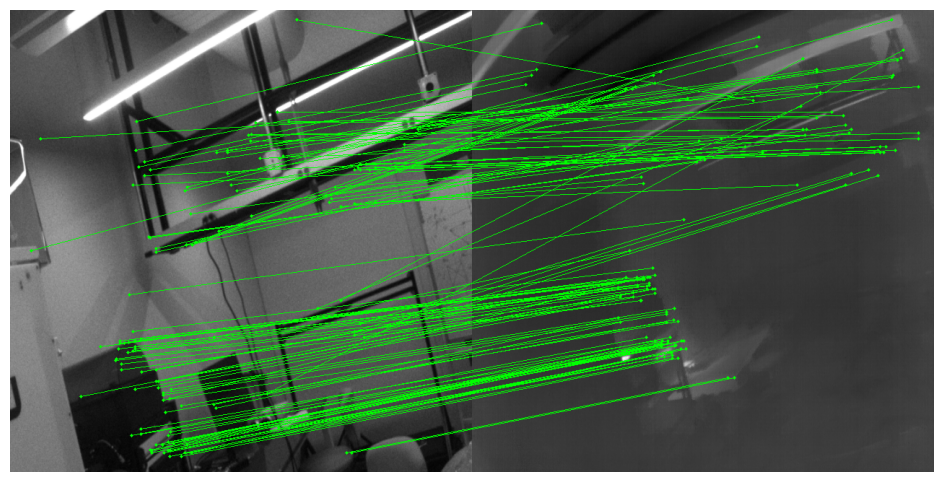

array([[[ 62,  62,  62],
        [ 60,  60,  60],
        [ 56,  56,  56],
        ...,
        [ 89,  89,  89],
        [ 85,  85,  85],
        [ 88,  88,  88]],

       [[ 58,  58,  58],
        [ 64,  64,  64],
        [ 61,  61,  61],
        ...,
        [ 89,  89,  89],
        [ 86,  86,  86],
        [ 86,  86,  86]],

       [[ 57,  57,  57],
        [ 61,  61,  61],
        [ 62,  62,  62],
        ...,
        [ 89,  89,  89],
        [ 87,  87,  87],
        [ 86,  86,  86]],

       ...,

       [[115, 115, 115],
        [122, 122, 122],
        [121, 121, 121],
        ...,
        [ 67,  67,  67],
        [ 67,  67,  67],
        [ 66,  66,  66]],

       [[118, 118, 118],
        [118, 118, 118],
        [118, 118, 118],
        ...,
        [ 66,  66,  66],
        [ 67,  67,  67],
        [ 65,  65,  65]],

       [[119, 119, 119],
        [114, 114, 114],
        [115, 115, 115],
        ...,
        [ 65,  65,  65],
        [ 67,  67,  67],
        [ 65,  65,  65]]

In [36]:
cfg_path  = REPO_ROOT / "configs/models/eloftr_model.py"
ckpt_path = REPO_ROOT / "weights/matchanything_eloftr.ckpt"
img_rgb_path = REPO_ROOT / "imgs/rgb0.png"
img_ir_path = REPO_ROOT / "imgs/ir0.png"

resize = 640  # or None to keep original size

mkpts_rgb, mkpts_ir, mconf, img_rgb, img_ir = match_two_images(
    img0_path=img_rgb_path,
    img1_path=img_ir_path,
    cfg_path=cfg_path,
    ckpt_path=ckpt_path,
    resize=resize,
)

# print(f"#matches: {mkpts_rgb.shape[0]}")
# print("First 10 matches (x0, y0) -> (x1, y1), conf:")
# for i in range(min(10, mkpts_rgb.shape[0])):
#     print(mkpts_rgb[i], "->", mkpts_ir[i], "conf =", mconf[i])

visualize_matches(img_rgb, img_ir, mkpts_rgb, mkpts_ir)


In [37]:
K_rgb0 = np.array([[530.81,   0.  , 321.28],
                   [  0.  , 536.08, 256.15],
                   [  0.  ,   0.  ,   1.  ]], dtype=np.float64)

d_rgb0 = np.array([-0.47929, 0.31437, 0.00090899, 0.00024121, 0.0], dtype=np.float64)

K_rgb1 = np.array([[556.42,   0.  , 320.77],
                   [  0.  , 562.60, 255.48],
                   [  0.  ,   0.  ,   1.  ]], dtype=np.float64)

d_rgb1 = np.array([-0.5494, 0.48069, 0.00072519, -0.00024657, 0.0], dtype=np.float64)

d_ir0 = np.array([-0.20450164833719758,
                  0.14743367885666747,
                  1.3691017237135784e-05,
                 -0.00029960779673081914,
                  0.0], dtype=np.float64)

d_ir1 = np.array([-0.19543806353197976,
                  0.12250750911745852,
                 -0.0008848056641066484,
                 -0.0021017501699217554,
                  0.0], dtype=np.float64)

K_ir0 = np.array([1275.5155246873633, 0.0, 656.6967116430126,
                  0.0, 1276.6709737523597, 506.5433446279619,
                  0.0, 0.0, 1.0], dtype=np.float64).reshape(3, 3)

K_ir1 = np.array([1252.4067462338985, 0.0, 629.4308621564376,
                  0.0, 1250.9809134660086, 513.5942922153134,
                  0.0, 0.0, 1.0], dtype=np.float64).reshape(3, 3)



In [38]:
rgb_pts = mkpts_rgb.reshape(-1, 1, 2)
ir_pts  = mkpts_ir.reshape(-1, 1, 2)

# Undistort to *rectified* normalized pixel coords with same K out
rgb_ud = cv2.undistortPoints(rgb_pts, K_rgb0, d_rgb0, P=K_rgb0)  # -> (N,1,2)
ir_ud  = cv2.undistortPoints(ir_pts,  K_ir0,  d_ir0,  P=K_ir0)

rgb_ud = rgb_ud.reshape(-1, 2)
ir_ud  = ir_ud.reshape(-1, 2)

F, mask_F = cv2.findFundamentalMat(
    rgb_ud, ir_ud,
    method=cv2.FM_RANSAC,
    ransacReprojThreshold=1.0,
    confidence=0.99
)

mask_F = mask_F.ravel().astype(bool)
rgb_inliers = rgb_ud[mask_F]
ir_inliers  = ir_ud[mask_F]

E = K_ir0.T @ F @ K_rgb0

_, R_est, t_est, mask_pose = cv2.recoverPose(
    E,
    rgb_ud,
    ir_ud,
    cameraMatrix=K_rgb0
)
print("Estimated R:\n", R_est)
print("Estimated t:\n", t_est)

Estimated R:
 [[ 0.99522683  0.01947871 -0.09562501]
 [-0.0382646   0.97930089 -0.19876013]
 [ 0.08977406  0.20147047  0.97537186]]
Estimated t:
 [[ 0.2896445 ]
 [ 0.19965343]
 [-0.93607936]]


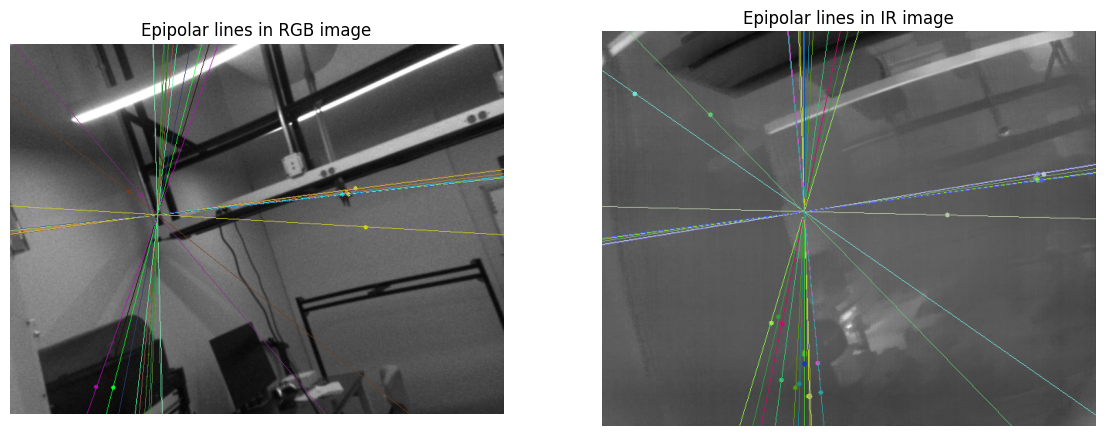

(array([[[129, 129, 129],
         [134, 134, 134],
         [133, 133, 133],
         ...,
         [ 60,  60,  60],
         [ 66,  66,  66],
         [ 69,  69,  69]],
 
        [[123, 123, 123],
         [115, 115, 115],
         [115, 115, 115],
         ...,
         [ 57,  57,  57],
         [ 59,  59,  59],
         [ 61,  61,  61]],
 
        [[111, 111, 111],
         [100, 100, 100],
         [ 99,  99,  99],
         ...,
         [ 54,  54,  54],
         [ 60,  60,  60],
         [ 64,  64,  64]],
 
        ...,
 
        [[118, 118, 118],
         [120, 120, 120],
         [121, 121, 121],
         ...,
         [ 46,  46,  46],
         [ 47,  47,  47],
         [ 46,  46,  46]],
 
        [[119, 119, 119],
         [121, 121, 121],
         [123, 123, 123],
         ...,
         [ 46,  46,  46],
         [ 43,  43,  43],
         [ 44,  44,  44]],
 
        [[125, 125, 125],
         [121, 121, 121],
         [125, 125, 125],
         ...,
         [ 45,  45,  45],
  

In [39]:
rgb_img = cv2.imread("imgs/rgb0.png", cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
ir_img  = cv2.imread("imgs/ir1.png",  cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

rgb_img_ud = cv2.undistort(rgb_img, K_rgb0, d_rgb0)
ir_img_ud  = cv2.undistort(ir_img,  K_ir0,  d_ir0)

# 4) draw epipolar lines
show_epipolar_lines(
    rgb_img_ud,
    ir_img_ud,
    rgb_inliers,
    ir_inliers,
    F,
    sample_step=1  # draw every 5th line for clarity
)

In [40]:
img0 = cv2.imread("imgs/rgb0.png", cv2.IMREAD_GRAYSCALE)
img1 = cv2.imread("imgs/rgb1.png", cv2.IMREAD_GRAYSCALE)
h, w = img0.shape[:2]

R_01 = np.eye(3)
T_01 = np.array([[0.31], [0.0], [0.0]], dtype=np.float64)

# Stereo rectification
R0, R1, P0, P1, Q, _, _ = cv2.stereoRectify(
    K_rgb0, d_rgb0,
    K_rgb1, d_rgb1,
    (w, h),
    R_01, T_01,
    flags=cv2.CALIB_ZERO_DISPARITY,
    alpha=0
)
K0_rect = P0[:, :3].copy()
map0x, map0y = cv2.initUndistortRectifyMap(
    K_rgb0, d_rgb0, R0, P0, (w, h), cv2.CV_32FC1
)
map1x, map1y = cv2.initUndistortRectifyMap(
    K_rgb1, d_rgb1, R1, P1, (w, h), cv2.CV_32FC1
)

rect0 = cv2.remap(img0, map0x, map0y, cv2.INTER_LINEAR)
rect1 = cv2.remap(img1, map1x, map1y, cv2.INTER_LINEAR)


In [41]:
min_disp = 0
num_disp = 128  # must be divisible by 16
block_size = 5

stereo = cv2.StereoSGBM_create(
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=block_size,
    P1=8 * 3 * block_size**2,
    P2=32 * 3 * block_size**2,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
)

disp = stereo.compute(rect0, rect1).astype(np.float32) / 16.0  # disparity in pixels

points_3d = cv2.reprojectImageTo3D(disp, Q)



In [42]:
pts_rgb = mkpts_rgb.reshape(-1, 1, 2).astype(np.float32)

# Map original cam0 pixels → rectified left camera pixels
pts_rgb_rect = cv2.undistortPoints(
    pts_rgb,
    K_rgb0, d_rgb0,
    R=R0, P=K0_rect
)  # (N,1,2)

mkpts_rgb_rect = pts_rgb_rect.reshape(-1, 2)  # N×2

pts3d = []
pts2_ir = []

H, W = disp.shape

cnt_total = 0
cnt_oob = 0
cnt_bad_disp = 0
cnt_bad_z = 0

for (u_ir, v_ir), (u_rgb_rect, v_rgb_rect) in zip(mkpts_ir, mkpts_rgb_rect):
    cnt_total += 1

    u = int(round(u_rgb_rect))
    v = int(round(v_rgb_rect))

    if u < 0 or u >= W or v < 0 or v >= H:
        cnt_oob += 1
        continue

    d_val = disp[v, u]
    if d_val <= 0 or np.isinf(d_val) or np.isnan(d_val):
        cnt_bad_disp += 1
        continue

    X, Y, Z = points_3d[v, u]
    if Z <= 0 or not np.isfinite(Z):
        cnt_bad_z += 1
        continue

    pts3d.append([X, Y, Z])
    pts2_ir.append([u_ir, v_ir])

print("total matches:", cnt_total)
print("out of bounds:", cnt_oob)
print("bad disparity:", cnt_bad_disp)
print("bad Z:", cnt_bad_z)
print("kept:", len(pts3d))

pts3d = np.asarray(pts3d, dtype=np.float32)
pts2_ir = np.asarray(pts2_ir, dtype=np.float32)

print("3D-2D pairs:", pts3d.shape[0])
print("pts3d shape:", pts3d.shape, pts3d.dtype)
print("pts2_ir shape:", pts2_ir.shape, pts2_ir.dtype)
print("mkpts_rgb_rect shape:", mkpts_rgb_rect.shape, mkpts_rgb_rect.dtype)

print("img_rgb shape:", img_rgb.shape)     # H_resized, W_resized, 3
print("disp shape:", disp.shape)           # H_rect, W_rect
print("mkpts_rgb min/max:",
      mkpts_rgb[:,0].min(), mkpts_rgb[:,0].max(),
      mkpts_rgb[:,1].min(), mkpts_rgb[:,1].max())

success, rvec, tvec, inliers = cv2.solvePnPRansac(
    pts3d,          # Nx3, 3D points in rectified RGB0 frame
    pts2_ir,        # Nx2, 2D points in IR image
    K_ir0, d_ir0,     # IR intrinsics + distortion
    iterationsCount=2000,
    reprojectionError=2.0,
    confidence=0.999,
    flags=cv2.SOLVEPNP_ITERATIVE,
)

if not success:
    raise RuntimeError("PnP failed")

R_ir, _ = cv2.Rodrigues(rvec)

print("R_ir (RGB0-rect -> IR):\n", R_ir)
print("t_ir (RGB0-rect -> IR):\n", tvec.reshape(-1))
print("#inliers:", len(inliers))

total matches: 123
out of bounds: 41
bad disparity: 44
bad Z: 38
kept: 0
3D-2D pairs: 0
pts3d shape: (0,) float32
pts2_ir shape: (0,) float32
mkpts_rgb_rect shape: (123, 2) float32
img_rgb shape: (640, 640)
disp shape: (540, 720)
mkpts_rgb min/max: 29.5 568.5 13.5 618.5


error: OpenCV(4.12.0) /io/opencv/modules/calib3d/src/solvepnp.cpp:239: error: (-215:Assertion failed) npoints >= 4 && npoints == std::max(ipoints.checkVector(2, CV_32F), ipoints.checkVector(2, CV_64F)) in function 'solvePnPRansac'


In [44]:
# === Stereo rectification and disparity (RGB0 / RGB1) ===
img0 = cv2.imread("imgs/rgb0.png", cv2.IMREAD_GRAYSCALE)
img1 = cv2.imread("imgs/rgb1.png", cv2.IMREAD_GRAYSCALE)
h0, w0 = img0.shape[:2]

R_01 = np.eye(3)
T_01 = np.array([[0.31], [0.0], [0.0]], dtype=np.float64)

R0, R1, P0, P1, Q, _, _ = cv2.stereoRectify(
    K_rgb0, d_rgb0,
    K_rgb1, d_rgb1,
    (w0, h0),
    R_01, T_01,
    flags=cv2.CALIB_ZERO_DISPARITY,
    alpha=0,
)

# Rectified intrinsics
K0_rect = P0[:, :3].copy()
K1_rect = P1[:, :3].copy()

map0x, map0y = cv2.initUndistortRectifyMap(
    K_rgb0, d_rgb0, R0, K0_rect, (w0, h0), cv2.CV_32FC1
)
map1x, map1y = cv2.initUndistortRectifyMap(
    K_rgb1, d_rgb1, R1, K1_rect, (w0, h0), cv2.CV_32FC1
)

rect0 = cv2.remap(img0, map0x, map0y, cv2.INTER_LINEAR)
rect1 = cv2.remap(img1, map1x, map1y, cv2.INTER_LINEAR)

min_disp = 0
num_disp = 128  # must be divisible by 16
block_size = 5

stereo = cv2.StereoSGBM_create(
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=block_size,
    P1=8 * 3 * block_size**2,
    P2=32 * 3 * block_size**2,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
)

disp = stereo.compute(rect0, rect1).astype(np.float32) / 16.0
points_3d = cv2.reprojectImageTo3D(disp, Q)

# === Map LoFTR matches back to original resolutions ===
# img_rgb is the resized RGB image returned by match_two_images

h_resized, w_resized = img_rgb.shape[:2]

# Original RGB0 size (used for rectification / disparity)
h_rgb0, w_rgb0 = img0.shape[:2]

# Original IR0 size
img_ir0 = cv2.imread("imgs/ir0.png", cv2.IMREAD_GRAYSCALE)
h_ir0, w_ir0 = img_ir0.shape[:2]

# Scale factors from resized (LoFTR) space to original images
scale_x_rgb = w_rgb0 / float(w_resized)
scale_y_rgb = h_rgb0 / float(h_resized)
scale_x_ir  = w_ir0 / float(w_resized)
scale_y_ir  = h_ir0 / float(h_resized)

mkpts_rgb_full = mkpts_rgb.astype(np.float32).copy()
mkpts_ir_full  = mkpts_ir.astype(np.float32).copy()

# Undo resize for RGB0 matches
mkpts_rgb_full[:, 0] *= scale_x_rgb
mkpts_rgb_full[:, 1] *= scale_y_rgb

# Undo resize for IR0 matches
mkpts_ir_full[:, 0]  *= scale_x_ir
mkpts_ir_full[:, 1]  *= scale_y_ir

# === Rectify RGB0 keypoints to rectified-left frame ===
pts_rgb = mkpts_rgb_full.reshape(-1, 1, 2)

pts_rgb_rect = cv2.undistortPoints(
    pts_rgb,
    K_rgb0, d_rgb0,
    R=R0, P=K0_rect,
)  # (N,1,2)
mkpts_rgb_rect = pts_rgb_rect.reshape(-1, 2)  # N×2

# === Build 3D–2D correspondences (rectified RGB0 → IR0) ===
pts3d = []
pts2_ir = []

H, W = disp.shape

cnt_total = 0
cnt_oob = 0
cnt_bad_disp = 0
cnt_bad_z = 0

for (u_ir, v_ir), (u_rgb_rect, v_rgb_rect) in zip(mkpts_ir_full, mkpts_rgb_rect):
    cnt_total += 1

    u = int(round(u_rgb_rect))
    v = int(round(v_rgb_rect))

    if u < 0 or u >= W or v < 0 or v >= H:
        cnt_oob += 1
        continue

    d_val = disp[v, u]
    if d_val <= 0 or not np.isfinite(d_val):
        cnt_bad_disp += 1
        continue

    X, Y, Z = points_3d[v, u]
    if not np.isfinite(Z):
        cnt_bad_z += 1
        continue

    pts3d.append([X, Y, Z])
    pts2_ir.append([u_ir, v_ir])

print("total matches:", cnt_total)
print("out of bounds:", cnt_oob)
print("bad disparity:", cnt_bad_disp)
print("bad Z:", cnt_bad_z)
print("kept:", len(pts3d))

pts3d = np.asarray(pts3d, dtype=np.float32)
pts2_ir = np.asarray(pts2_ir, dtype=np.float32)

print("3D-2D pairs:", pts3d.shape[0])
print("pts3d shape:", pts3d.shape, pts3d.dtype)
print("pts2_ir shape:", pts2_ir.shape, pts2_ir.dtype)

if pts3d.shape[0] < 4:
    raise RuntimeError(f"Not enough 3D-2D pairs for PnP: {pts3d.shape[0]}")

# === PnP: rectified RGB0 3D → original IR0 2D ===
success, rvec, tvec, inliers = cv2.solvePnPRansac(
    pts3d,          # Nx3, 3D points in rectified RGB0 frame
    pts2_ir,        # Nx2, 2D points in original IR0 image
    K_ir0, d_ir0,   # IR0 intrinsics + distortion
    iterationsCount=2000,
    reprojectionError=2.0,
    confidence=0.999,
    flags=cv2.SOLVEPNP_ITERATIVE,
)

if not success or inliers is None:
    raise RuntimeError("PnP failed")

R_ir, _ = cv2.Rodrigues(rvec)

print("R_ir (RGB0-rect -> IR0):\n", R_ir)
print("t_ir (RGB0-rect -> IR0):\n", tvec.reshape(-1))
print("#inliers:", len(inliers))


total matches: 123
out of bounds: 5
bad disparity: 47
bad Z: 0
kept: 71
3D-2D pairs: 71
pts3d shape: (71, 3) float32
pts2_ir shape: (71, 2) float32
R_ir (RGB0-rect -> IR0):
 [[-0.98706341  0.11564705 -0.11104764]
 [-0.07987579 -0.95524633 -0.28482331]
 [-0.13901682 -0.27226865  0.9521261 ]]
t_ir (RGB0-rect -> IR0):
 [-1.00786745 -1.2796977   4.92895532]
#inliers: 6
